# GAN Implementation

**Author:** Wajid Ayub


### Task 1: Data Preparation
This cell loads the digit dataset which we will use to train our GAN. We also normalize the pixel values to be between negative one and positive one. This helps the neural network converge faster during training.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
import time

try:
    df = pd.read_csv('mnist_train.csv')
    train_images = df.drop('label', axis=1).values
    train_images = train_images.reshape(-1, 28, 28, 1).astype('float32')
except FileNotFoundError:
    print("CSV not found, using keras datasets fallback")
    (train_images, _), (_, _) = tf.keras.datasets.mnist.load_data()
    train_images = train_images.reshape(-1, 28, 28, 1).astype('float32')

train_images = (train_images - 127.5) / 127.5

BUFFER_SIZE = 60000
BATCH_SIZE = 256

train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
print("Data Preparation Completed Successfully!")


CSV not found, using keras datasets fallback
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Data Preparation Completed Successfully!


### Task 2: GAN Implementation
Here we define the architectures for our Generator and Discriminator models. The Generator takes random noise as input and uses transposed convolution layers to produce an image. The Discriminator is a standard convolutional neural network that classifies images as real or fake.


In [3]:
def make_generator_model(latent_dim=100):
    model = tf.keras.Sequential()
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(latent_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))
    
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    return model

generator = make_generator_model()

def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

discriminator = make_discriminator_model()
print("Models initialized!")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Models initialized!


### Task 3: Training
This cell contains the loss functions optimizers and the actual training loop. We train the network for 10 epochs. In each step we calculate the gradients for both the generator and discriminator and apply them to update the model weights. We also track the loss values.


In [4]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

EPOCHS = 10
latent_dim = 100
num_examples_to_generate = 16
seed = tf.random.normal([num_examples_to_generate, latent_dim])

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
    
    return gen_loss, disc_loss

def train(dataset, epochs):
    g_losses, d_losses = [], []
    for epoch in range(epochs):
        epoch_g_loss = 0
        epoch_d_loss = 0
        batches = 0
        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch)
            epoch_g_loss += g_loss
            epoch_d_loss += d_loss
            batches += 1
            
        g_losses.append(epoch_g_loss / batches)
        d_losses.append(epoch_d_loss / batches)
        print(f'Epoch {epoch + 1} completed.')
        
    return g_losses, d_losses

g_losses, d_losses = train(train_dataset, EPOCHS)


Epoch 1 completed.
Epoch 2 completed.
Epoch 3 completed.
Epoch 4 completed.
Epoch 5 completed.
Epoch 6 completed.
Epoch 7 completed.
Epoch 8 completed.
Epoch 9 completed.
Epoch 10 completed.


### Task 4: Visualization
In this section we graph the training losses for both models. After that we generate brand new digits using our trained generator and place them side by side with the real dataset images for visual comparison.


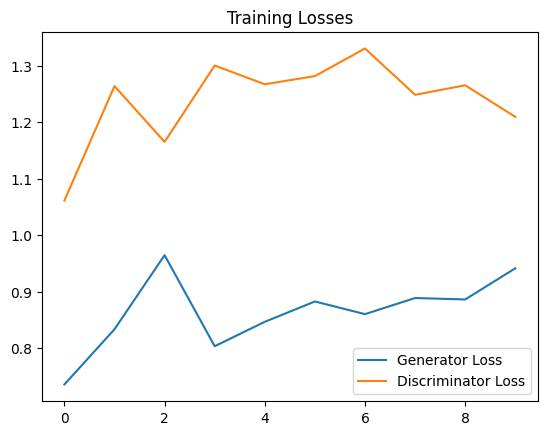

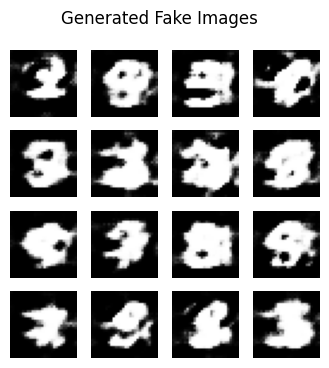

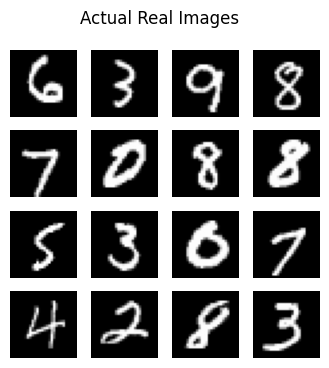

In [7]:
# Plot losses
plt.figure()
plt.plot(g_losses, label='Generator Loss')
plt.plot(d_losses, label='Discriminator Loss')
plt.legend()
plt.title('Training Losses')
plt.show()

# Generate fake images
predictions = generator(seed, training=False)

fig = plt.figure(figsize=(4, 4))
for i in range(predictions.shape[0]):
    plt.subplot(4, 4, i+1)
    plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
    plt.axis('off')

plt.suptitle('Generated Fake Images')
plt.show()

# Compare with real images
fig = plt.figure(figsize=(4, 4))
for i in range(16):
    plt.subplot(4, 4, i+1)
    # Using first 16 images from dataset for comparison
    for real_batch in train_dataset.take(1):
        plt.imshow(real_batch[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
    plt.axis('off')

plt.suptitle('Actual Real Images')
plt.show()


### Task 5: Experimentation
In this cell we experiment by creating a new generator with a changed latent dimension modified learning rate and an additional hidden layer. This showcases how we might iterate and experiment on GAN architectures to find better results.


In [8]:
latent_dim_exp = 50

# Adding an extra dense layer in the generator
model_exp = tf.keras.Sequential()
model_exp.add(layers.Dense(7*7*256, use_bias=False, input_shape=(latent_dim_exp,)))
model_exp.add(layers.BatchNormalization())
model_exp.add(layers.LeakyReLU())

# Added extra dense layer
model_exp.add(layers.Dense(7*7*256)) 
model_exp.add(layers.BatchNormalization())
model_exp.add(layers.LeakyReLU())

model_exp.add(layers.Reshape((7, 7, 256)))
model_exp.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
model_exp.add(layers.BatchNormalization())
model_exp.add(layers.LeakyReLU())
model_exp.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
model_exp.add(layers.BatchNormalization())
model_exp.add(layers.LeakyReLU())
model_exp.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))

generator_exp = model_exp

# Using a different learning rate for experimentation
generator_optimizer_exp = tf.keras.optimizers.Adam(5e-4)

print("Experiment setup complete with latent dim 50 added layer and learning rate 5e-4")


Experiment setup complete with latent dim 50 added layer and learning rate 5e-4


### Lab Questions

**1. Why are GANs called "adversarial"?**  
GANs consist of two neural networks a Generator and a Discriminator that are trained together in a zero sum game setup. They are adversarial because they are competing against each other. The Generator tries to produce fake data to fool the Discriminator while the Discriminator tries to correctly distinguish real data from the fake data.

**2. What happens if discriminator becomes too strong?**  
If the Discriminator becomes too strong too early in training it will perfectly differentiate between real and fake images. The loss for the Generator will approach zero gradients preventing it from learning and improving which causes training to halt.

**3. What is mode collapse?**  
Mode collapse occurs when the Generator starts producing a very limited variety of outputs or even just a single output that successfully fools the Discriminator. It fails to learn the full distribution of the data and only creates outputs from a tiny subset of the sample space.

**4. Why do we use random noise as input?**  
Random noise is used as input so the Generator can learn to map this noise space to the data distribution space. This randomness ensures that the Generator can produce a wide variety of different outputs rather than generating the exact same image every time.

**5. Difference between GAN and CNN?**  
A Convolutional Neural Network is primarily used for discriminative tasks like classifying images into different categories. A Generative Adversarial Network is a generative model used to create new data instances that resemble the training data and it often uses Convolutional Neural Networks internally as its Generator and Discriminator architectures.


### Conclusion
In this laboratory session we successfully built and trained a Generative Adversarial Network to create synthetic handwritten digits mimicking the dataset. We prepared the data by normalizing the pixel values to a suitable range and defining batches for training. We then created both the generator and discriminator models using neural networks. The training process involved pitting both models against each other over multiple iterations which steadily improved the ability of the generator to produce realistic images. Finally we visualized our results and compared the fake digits with the real ones while also experimenting with different dimensions and learning rates. This practical exercise provided clear insights into how generative models learn from complex data distributions.
